In [1]:
!pip install wandb kaggle torch torchvision torchmetrics scikit-learn matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.5 MB/s eta 0:00:00


In [2]:
import wandb

wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: luchit22 (luchit22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [11]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_a659f6ff16c2a338ef2c422a632ea041"

In [12]:
!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [13]:
!kaggle competitions list | head

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [14]:
!kaggle datasets list -s fer2013

ref                                                        title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
deadskull7/fer2013                                         fer2013                                             101279992  2018-05-26 12:18:24.933000          65068        569  0.29411766       
nicolejyt/facialexpressionrecognition                      FER2013                                             101279992  2019-04-02 18:29:26.050000          13469         69  0.3529412        
fahadullaha/facial-emotion-recognition-dataset             Facial Emotion Recognition Dataset                  209818285  2025-09-30 08:05:11.797000           4675         79  1                
astraszab/facial-expression-da

In [15]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [16]:
!kaggle datasets download -d deadskull7/fer2013

Dataset URL: https://www.kaggle.com/datasets/deadskull7/fer2013
License(s): CC0-1.0
100% 96.6M/96.6M [00:00<00:00, 197MB/s]



In [17]:
!unzip fer2013.zip -d data

Archive:  fer2013.zip
  inflating: data/fer2013.csv        


In [18]:
import wandb

wandb.init(
    project="fer2013-homework",
    name="test_run"
)

wandb.log({"accuracy": 0.5})

wandb.finish()

accuracy,▁
accuracy,0.5


In [19]:
import pandas as pd

df = pd.read_csv("data/fer2013.csv")
print(df.shape)
df.head()

(35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [20]:
df["Usage"].value_counts()

,count
Usage,
Training,28709
PublicTest,3589
PrivateTest,3589


In [21]:
df["emotion"].value_counts().sort_index()

,count
emotion,
0,4953
1,547
2,5121
3,8989
4,6077
5,4002
6,6198


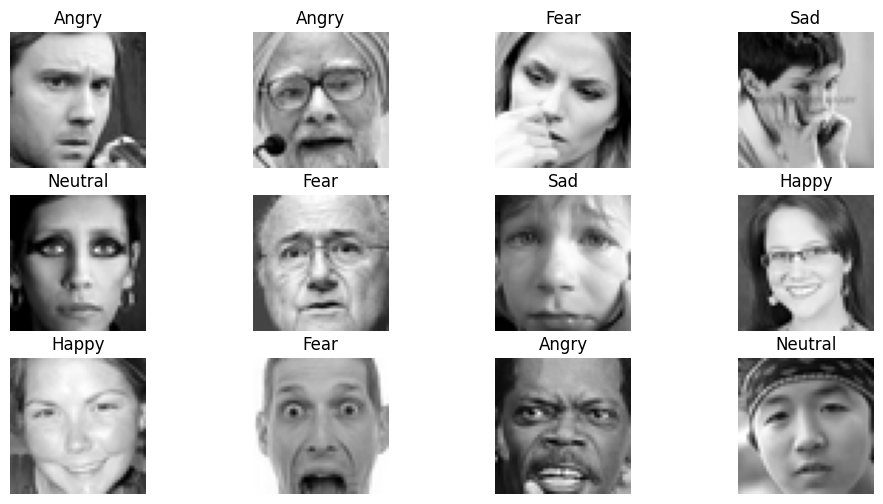

In [24]:
import numpy as np
import matplotlib.pyplot as plt

emotion_labels = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

plt.figure(figsize=(12, 6))

for i in range(12):
    pixels = np.array(df.iloc[i]["pixels"].split(), dtype=np.uint8).reshape(48, 48)
    label = df.iloc[i]["emotion"]

    plt.subplot(3, 4, i + 1)
    plt.imshow(pixels, cmap="gray")
    plt.title(emotion_labels[label])
    plt.axis("off")

plt.show()

In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FER2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = np.array(row["pixels"].split(), dtype=np.float32).reshape(48, 48)
        image = image / 255.0
        image = np.expand_dims(image, axis=0)

        label = int(row["emotion"])

        image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [25]:
train_df = df[df["Usage"] == "Training"]
val_df = df[df["Usage"] == "PublicTest"]
test_df = df[df["Usage"] == "PrivateTest"]

train_dataset = FER2013Dataset(train_df)
val_dataset = FER2013Dataset(val_df)
test_dataset = FER2013Dataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels[:10])

torch.Size([64, 1, 48, 48])
torch.Size([64])
tensor([0, 4, 2, 4, 2, 4, 0, 6, 2, 2])


In [26]:
import torch.nn as nn
import torch.nn.functional as F

class TinyCNN(nn.Module):
    def __init__(self):
        super(TinyCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 7)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 48 -> 24
        x = self.pool(F.relu(self.conv2(x)))   # 24 -> 12
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TinyCNN().to(device)
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

outputs = model(sample_images)

print(outputs.shape)

torch.Size([64, 7])


In [28]:
import torch.optim as optim
from sklearn.metrics import accuracy_score
import wandb

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [21]:
config = {
    "model": "TinyCNN",
    "epochs": 10,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="TinyCNN_baseline_lr0.001",
    config=config
)

model = TinyCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

wandb.finish()

Epoch [1/10], Train Loss: 1.6577, Train Acc: 0.3459, Val Loss: 1.5468, Val Acc: 0.4132
Epoch [2/10], Train Loss: 1.4817, Train Acc: 0.4324, Val Loss: 1.4173, Val Acc: 0.4592
Epoch [3/10], Train Loss: 1.3758, Train Acc: 0.4747, Val Loss: 1.3706, Val Acc: 0.4731
Epoch [4/10], Train Loss: 1.3016, Train Acc: 0.5043, Val Loss: 1.3332, Val Acc: 0.4893
Epoch [5/10], Train Loss: 1.2360, Train Acc: 0.5291, Val Loss: 1.2994, Val Acc: 0.4971
Epoch [6/10], Train Loss: 1.1803, Train Acc: 0.5549, Val Loss: 1.2821, Val Acc: 0.5091
Epoch [7/10], Train Loss: 1.1166, Train Acc: 0.5785, Val Loss: 1.3051, Val Acc: 0.5118
Epoch [8/10], Train Loss: 1.0584, Train Acc: 0.6030, Val Loss: 1.2911, Val Acc: 0.5121
Epoch [9/10], Train Loss: 0.9933, Train Acc: 0.6316, Val Loss: 1.2956, Val Acc: 0.5313
Epoch [10/10], Train Loss: 0.9317, Train Acc: 0.6551, Val Loss: 1.3213, Val Acc: 0.5263


epoch,▁▂▃▃▄▅▆▆▇█
train_accuracy,▁▃▄▅▅▆▆▇▇█
train_loss,█▆▅▅▄▃▃▂▂▁
val_accuracy,▁▄▅▆▆▇▇▇██
val_loss,█▅▃▂▁▁▂▁▁▂
epoch,10
train_accuracy,0.65506
train_loss,0.93174
val_accuracy,0.52633
val_loss,1.32125


In [29]:
class MediumCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super(MediumCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 48 -> 24

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 24 -> 12

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)    # 12 -> 6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [30]:
model = MediumCNN(dropout=0.3).to(device)
outputs = model(sample_images.to(device))
print(outputs.shape)

torch.Size([64, 7])


In [24]:
config = {
    "model": "MediumCNN",
    "epochs": 15,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "dropout": 0.3,
    "batch_norm": True,
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="MediumCNN_bn_dropout0.3_lr0.001",
    config=config
)

model = MediumCNN(dropout=config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

wandb.finish()

Epoch [1/15], Train Loss: 1.6784, Train Acc: 0.3285, Val Loss: 1.4456, Val Acc: 0.4294
Epoch [2/15], Train Loss: 1.3930, Train Acc: 0.4579, Val Loss: 1.2878, Val Acc: 0.5135
Epoch [3/15], Train Loss: 1.2768, Train Acc: 0.5074, Val Loss: 1.2124, Val Acc: 0.5294
Epoch [4/15], Train Loss: 1.2094, Train Acc: 0.5389, Val Loss: 1.1570, Val Acc: 0.5531
Epoch [5/15], Train Loss: 1.1558, Train Acc: 0.5557, Val Loss: 1.1576, Val Acc: 0.5422
Epoch [6/15], Train Loss: 1.1154, Train Acc: 0.5709, Val Loss: 1.1219, Val Acc: 0.5645
Epoch [7/15], Train Loss: 1.0732, Train Acc: 0.5876, Val Loss: 1.1114, Val Acc: 0.5687
Epoch [8/15], Train Loss: 1.0307, Train Acc: 0.6085, Val Loss: 1.1318, Val Acc: 0.5848
Epoch [9/15], Train Loss: 0.9956, Train Acc: 0.6221, Val Loss: 1.0798, Val Acc: 0.5826
Epoch [10/15], Train Loss: 0.9570, Train Acc: 0.6355, Val Loss: 1.0841, Val Acc: 0.5974
Epoch [11/15], Train Loss: 0.9211, Train Acc: 0.6481, Val Loss: 1.1026, Val Acc: 0.5960
Epoch [12/15], Train Loss: 0.8841, Train 

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▄▅▅▆▆▆▇▇▇▇███
train_loss,█▆▅▄▄▄▃▃▃▂▂▂▂▁▁
val_accuracy,▁▄▅▆▅▆▆▇▇██████
val_loss,█▅▄▃▃▂▂▂▁▁▂▁▁▂▂
epoch,15
train_accuracy,0.69891
train_loss,0.78396
val_accuracy,0.60546
val_loss,1.11107


In [25]:
config = {
    "model": "MediumCNN",
    "epochs": 15,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "dropout": 0.5,
    "weight_decay": 1e-4,
    "batch_norm": True,
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="MediumCNN_dropout0.5_weightdecay1e-4",
    config=config
)

model = MediumCNN(dropout=config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

wandb.finish()

Epoch [1/15], Train Loss: 1.7494, Train Acc: 0.2847, Val Loss: 1.5108, Val Acc: 0.4124
Epoch [2/15], Train Loss: 1.5625, Train Acc: 0.3695, Val Loss: 1.3903, Val Acc: 0.4642
Epoch [3/15], Train Loss: 1.4906, Train Acc: 0.4062, Val Loss: 1.3691, Val Acc: 0.4659
Epoch [4/15], Train Loss: 1.4458, Train Acc: 0.4263, Val Loss: 1.3472, Val Acc: 0.4854
Epoch [5/15], Train Loss: 1.4064, Train Acc: 0.4434, Val Loss: 1.2745, Val Acc: 0.4999
Epoch [6/15], Train Loss: 1.3801, Train Acc: 0.4552, Val Loss: 1.2753, Val Acc: 0.5096
Epoch [7/15], Train Loss: 1.3460, Train Acc: 0.4669, Val Loss: 1.2455, Val Acc: 0.5135
Epoch [8/15], Train Loss: 1.3257, Train Acc: 0.4777, Val Loss: 1.2280, Val Acc: 0.5277
Epoch [9/15], Train Loss: 1.2958, Train Acc: 0.4913, Val Loss: 1.2199, Val Acc: 0.5336
Epoch [10/15], Train Loss: 1.2721, Train Acc: 0.5016, Val Loss: 1.2106, Val Acc: 0.5391
Epoch [11/15], Train Loss: 1.2431, Train Acc: 0.5103, Val Loss: 1.2200, Val Acc: 0.5386
Epoch [12/15], Train Loss: 1.2204, Train 

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▃▄▅▅▅▆▆▆▇▇▇▇██
train_loss,█▆▅▅▄▄▃▃▃▃▂▂▂▁▁
val_accuracy,▁▃▃▄▅▆▆▆▇▇▇▇██▇
val_loss,█▆▅▅▃▃▃▂▂▂▂▁▁▁▂
epoch,15
train_accuracy,0.55627
train_loss,1.14104
val_accuracy,0.54778
val_loss,1.19861


In [31]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10)
])

val_transform = None

In [32]:
class FER2013Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = np.array(
            row["pixels"].split(),
            dtype=np.float32
        ).reshape(48, 48)

        image = image / 255.0

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).unsqueeze(0)

        if self.transform:
            image = self.transform(image)

        label = int(row["emotion"])

        return image, label

In [33]:
train_dataset = FER2013Dataset(
    train_df,
    transform=train_transform
)

val_dataset = FER2013Dataset(
    val_df
)

test_dataset = FER2013Dataset(
    test_df
)

In [34]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10)
])

In [35]:
train_dataset = FER2013Dataset(train_df, transform=train_transform)
val_dataset = FER2013Dataset(val_df, transform=None)
test_dataset = FER2013Dataset(test_df, transform=None)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [31]:
config = {
    "model": "MediumCNN",
    "epochs": 15,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "dropout": 0.3,
    "augmentation": "RandomHorizontalFlip + RandomRotation",
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="MediumCNN_dropout0.3_augmentation_lr0.001",
    config=config
)

model = MediumCNN(dropout=config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

wandb.finish()

Epoch [1/15], Train Loss: 1.6882, Train Acc: 0.3219, Val Loss: 1.4426, Val Acc: 0.4349
Epoch [2/15], Train Loss: 1.4277, Train Acc: 0.4472, Val Loss: 1.3111, Val Acc: 0.5010
Epoch [3/15], Train Loss: 1.3410, Train Acc: 0.4846, Val Loss: 1.3041, Val Acc: 0.4962
Epoch [4/15], Train Loss: 1.2928, Train Acc: 0.5044, Val Loss: 1.2080, Val Acc: 0.5283
Epoch [5/15], Train Loss: 1.2526, Train Acc: 0.5244, Val Loss: 1.1879, Val Acc: 0.5378
Epoch [6/15], Train Loss: 1.2228, Train Acc: 0.5337, Val Loss: 1.1503, Val Acc: 0.5531
Epoch [7/15], Train Loss: 1.1967, Train Acc: 0.5459, Val Loss: 1.2169, Val Acc: 0.5411
Epoch [8/15], Train Loss: 1.1772, Train Acc: 0.5531, Val Loss: 1.1343, Val Acc: 0.5589
Epoch [9/15], Train Loss: 1.1599, Train Acc: 0.5592, Val Loss: 1.0951, Val Acc: 0.5840
Epoch [10/15], Train Loss: 1.1423, Train Acc: 0.5638, Val Loss: 1.1093, Val Acc: 0.5731
Epoch [11/15], Train Loss: 1.1313, Train Acc: 0.5705, Val Loss: 1.0808, Val Acc: 0.5977
Epoch [12/15], Train Loss: 1.1122, Train 

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_accuracy,▁▄▅▆▆▆▇▇▇▇▇████
train_loss,█▅▄▃▃▃▂▂▂▂▂▁▁▁▁
val_accuracy,▁▄▄▅▅▆▆▆▇▇██▇██
val_loss,█▆▆▄▃▃▄▃▂▂▂▁▂▁▁
epoch,15
train_accuracy,0.59194
train_loss,1.07463
val_accuracy,0.59933
val_loss,1.06489


In [36]:
config = {
    "model": "MediumCNN",
    "epochs": 25,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "dropout": 0.3,
    "augmentation": "RandomHorizontalFlip + RandomRotation",
    "scheduler": "StepLR step_size=10 gamma=0.5",
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="MediumCNN_aug_scheduler_25epochs",
    config=config
)

model = MediumCNN(dropout=config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    current_lr = optimizer.param_groups[0]["lr"]

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "learning_rate": current_lr
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"LR: {current_lr:.6f}, "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

    scheduler.step()

wandb.finish()

Epoch [1/25], LR: 0.001000, Train Loss: 1.7785, Train Acc: 0.2829, Val Loss: 1.7127, Val Acc: 0.3541
Epoch [2/25], LR: 0.001000, Train Loss: 1.5151, Train Acc: 0.4024, Val Loss: 1.3774, Val Acc: 0.4517
Epoch [3/25], LR: 0.001000, Train Loss: 1.3969, Train Acc: 0.4567, Val Loss: 1.3021, Val Acc: 0.4926
Epoch [4/25], LR: 0.001000, Train Loss: 1.3388, Train Acc: 0.4810, Val Loss: 1.2461, Val Acc: 0.5174
Epoch [5/25], LR: 0.001000, Train Loss: 1.3079, Train Acc: 0.4938, Val Loss: 1.2130, Val Acc: 0.5327
Epoch [6/25], LR: 0.001000, Train Loss: 1.2775, Train Acc: 0.5073, Val Loss: 1.2317, Val Acc: 0.5311
Epoch [7/25], LR: 0.001000, Train Loss: 1.2518, Train Acc: 0.5164, Val Loss: 1.1610, Val Acc: 0.5520
Epoch [8/25], LR: 0.001000, Train Loss: 1.2311, Train Acc: 0.5309, Val Loss: 1.1625, Val Acc: 0.5495
Epoch [9/25], LR: 0.001000, Train Loss: 1.2145, Train Acc: 0.5327, Val Loss: 1.1297, Val Acc: 0.5656
Epoch [10/25], LR: 0.001000, Train Loss: 1.1991, Train Acc: 0.5401, Val Loss: 1.1404, Val A

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
learning_rate,██████████▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁
train_accuracy,▁▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇███████
train_loss,█▆▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_accuracy,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇█████████
val_loss,█▅▄▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,25
learning_rate,0.00025
train_accuracy,0.60796
train_loss,1.03807
val_accuracy,0.6088


In [37]:
class DeepCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super(DeepCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 7)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [38]:
config = {
    "model": "DeepCNN",
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "dropout": 0.4,
    "augmentation": "RandomHorizontalFlip + RandomRotation",
    "scheduler": "StepLR step_size=10 gamma=0.5",
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="DeepCNN_aug_dropout0.4_scheduler_30epochs",
    config=config
)

model = DeepCNN(dropout=config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_val_acc = 0.0

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_deepcnn.pth")

    current_lr = optimizer.param_groups[0]["lr"]

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "learning_rate": current_lr,
        "best_val_accuracy": best_val_acc
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"LR: {current_lr:.6f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Acc: {val_acc:.4f}, "
        f"Best Val Acc: {best_val_acc:.4f}"
    )

    scheduler.step()

wandb.finish()

Epoch [1/30], LR: 0.001000, Train Acc: 0.3601, Val Acc: 0.4179, Best Val Acc: 0.4179
Epoch [2/30], LR: 0.001000, Train Acc: 0.4829, Val Acc: 0.4890, Best Val Acc: 0.4890
Epoch [3/30], LR: 0.001000, Train Acc: 0.5251, Val Acc: 0.5210, Best Val Acc: 0.5210
Epoch [4/30], LR: 0.001000, Train Acc: 0.5489, Val Acc: 0.5021, Best Val Acc: 0.5210
Epoch [5/30], LR: 0.001000, Train Acc: 0.5656, Val Acc: 0.5790, Best Val Acc: 0.5790
Epoch [6/30], LR: 0.001000, Train Acc: 0.5821, Val Acc: 0.5784, Best Val Acc: 0.5790
Epoch [7/30], LR: 0.001000, Train Acc: 0.5941, Val Acc: 0.5467, Best Val Acc: 0.5790
Epoch [8/30], LR: 0.001000, Train Acc: 0.6044, Val Acc: 0.5823, Best Val Acc: 0.5823
Epoch [9/30], LR: 0.001000, Train Acc: 0.6137, Val Acc: 0.5974, Best Val Acc: 0.5974
Epoch [10/30], LR: 0.001000, Train Acc: 0.6214, Val Acc: 0.6208, Best Val Acc: 0.6208
Epoch [11/30], LR: 0.000500, Train Acc: 0.6421, Val Acc: 0.6339, Best Val Acc: 0.6339
Epoch [12/30], LR: 0.000500, Train Acc: 0.6530, Val Acc: 0.6239

best_val_accuracy,▁▃▄▄▆▆▆▆▆▇▇▇▇▇▇▇▇▇████████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,██████████▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇████████
train_loss,█▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_accuracy,▁▃▄▃▆▆▅▆▆▇▇▇▇▇▇▇▇▇████████████
val_loss,█▅▅▅▃▃▄▃▂▁▁▁▂▂▁▂▂▁▁▂▁▁▁▁▁▁▁▂▁▂
best_val_accuracy,0.65952
epoch,30
learning_rate,0.00025
train_accuracy,0.74653


In [39]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False):
        super(ResidualBlock, self).__init__()

        stride = 2 if downsample else 1

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels)
        )

        self.shortcut = nn.Sequential()

        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv_block(x) + self.shortcut(x))


class ResidualCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super(ResidualCNN, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.layers = nn.Sequential(
            ResidualBlock(32, 64, downsample=True),
            ResidualBlock(64, 64),

            ResidualBlock(64, 128, downsample=True),
            ResidualBlock(128, 128),

            ResidualBlock(128, 256, downsample=True),
            ResidualBlock(256, 256),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 7)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layers(x)
        return self.classifier(x)

In [40]:
config = {
    "model": "ResidualCNN",
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "dropout": 0.4,
    "augmentation": "RandomHorizontalFlip + RandomRotation",
    "scheduler": "StepLR step_size=10 gamma=0.5",
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="ResidualCNN_aug_dropout0.4_scheduler_30epochs",
    config=config
)

model = ResidualCNN(dropout=config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_val_acc = 0.0

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_residualcnn.pth")

    current_lr = optimizer.param_groups[0]["lr"]

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "learning_rate": current_lr,
        "best_val_accuracy": best_val_acc
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"LR: {current_lr:.6f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Acc: {val_acc:.4f}, "
        f"Best Val Acc: {best_val_acc:.4f}"
    )

    scheduler.step()

wandb.finish()

Epoch [1/30], LR: 0.001000, Train Acc: 0.3560, Val Acc: 0.4759, Best Val Acc: 0.4759
Epoch [2/30], LR: 0.001000, Train Acc: 0.5001, Val Acc: 0.5096, Best Val Acc: 0.5096
Epoch [3/30], LR: 0.001000, Train Acc: 0.5447, Val Acc: 0.5564, Best Val Acc: 0.5564
Epoch [4/30], LR: 0.001000, Train Acc: 0.5710, Val Acc: 0.5865, Best Val Acc: 0.5865
Epoch [5/30], LR: 0.001000, Train Acc: 0.5931, Val Acc: 0.5536, Best Val Acc: 0.5865
Epoch [6/30], LR: 0.001000, Train Acc: 0.6017, Val Acc: 0.5756, Best Val Acc: 0.5865
Epoch [7/30], LR: 0.001000, Train Acc: 0.6165, Val Acc: 0.5717, Best Val Acc: 0.5865
Epoch [8/30], LR: 0.001000, Train Acc: 0.6291, Val Acc: 0.6004, Best Val Acc: 0.6004
Epoch [9/30], LR: 0.001000, Train Acc: 0.6375, Val Acc: 0.6052, Best Val Acc: 0.6052
Epoch [10/30], LR: 0.001000, Train Acc: 0.6508, Val Acc: 0.6133, Best Val Acc: 0.6133
Epoch [11/30], LR: 0.000500, Train Acc: 0.6839, Val Acc: 0.6336, Best Val Acc: 0.6336
Epoch [12/30], LR: 0.000500, Train Acc: 0.6956, Val Acc: 0.6439

best_val_accuracy,▁▂▄▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇████████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,██████████▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██████
train_loss,█▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
val_accuracy,▁▂▄▅▄▅▅▆▆▆▇▇▇▇▇▇▇▇█▇██▇███████
val_loss,█▆▄▃▅▃▄▂▂▂▁▁▁▂▁▁▁▂▂▃▃▃▅▅▅▅▆▇▇█
best_val_accuracy,0.66342
epoch,30
learning_rate,0.00025
train_accuracy,0.88756


In [41]:
config = {
    "model": "ResidualCNN",
    "epochs": 30,
    "batch_size": 64,
    "learning_rate": 0.001,
    "optimizer": "Adam",
    "dropout": 0.5,
    "weight_decay": 1e-4,
    "augmentation": "RandomHorizontalFlip + RandomRotation",
    "scheduler": "StepLR step_size=10 gamma=0.5",
    "loss": "CrossEntropyLoss"
}

wandb.init(
    project="fer2013-homework",
    name="ResidualCNN_dropout0.5_weightdecay1e-4_scheduler",
    config=config
)

model = ResidualCNN(dropout=config["dropout"]).to(device)
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

best_val_acc = 0.0

for epoch in range(config["epochs"]):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_residualcnn_regularized.pth")

    current_lr = optimizer.param_groups[0]["lr"]

    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "best_val_accuracy": best_val_acc,
        "learning_rate": current_lr
    })

    print(
        f"Epoch [{epoch+1}/{config['epochs']}], "
        f"LR: {current_lr:.6f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Acc: {val_acc:.4f}, "
        f"Best Val Acc: {best_val_acc:.4f}"
    )

    scheduler.step()

wandb.finish()

Epoch [1/30], LR: 0.001000, Train Acc: 0.3739, Val Acc: 0.4859, Best Val Acc: 0.4859
Epoch [2/30], LR: 0.001000, Train Acc: 0.4959, Val Acc: 0.4837, Best Val Acc: 0.4859
Epoch [3/30], LR: 0.001000, Train Acc: 0.5389, Val Acc: 0.5469, Best Val Acc: 0.5469
Epoch [4/30], LR: 0.001000, Train Acc: 0.5633, Val Acc: 0.5319, Best Val Acc: 0.5469
Epoch [5/30], LR: 0.001000, Train Acc: 0.5757, Val Acc: 0.5018, Best Val Acc: 0.5469
Epoch [6/30], LR: 0.001000, Train Acc: 0.5876, Val Acc: 0.5690, Best Val Acc: 0.5690
Epoch [7/30], LR: 0.001000, Train Acc: 0.6015, Val Acc: 0.5522, Best Val Acc: 0.5690
Epoch [8/30], LR: 0.001000, Train Acc: 0.6099, Val Acc: 0.5996, Best Val Acc: 0.5996
Epoch [9/30], LR: 0.001000, Train Acc: 0.6150, Val Acc: 0.5801, Best Val Acc: 0.5996
Epoch [10/30], LR: 0.001000, Train Acc: 0.6268, Val Acc: 0.6088, Best Val Acc: 0.6088
Epoch [11/30], LR: 0.000500, Train Acc: 0.6574, Val Acc: 0.6378, Best Val Acc: 0.6378
Epoch [12/30], LR: 0.000500, Train Acc: 0.6710, Val Acc: 0.6353

best_val_accuracy,▁▁▃▃▃▄▄▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,██████████▃▃▃▃▃▃▃▃▃▃▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇█████
train_loss,█▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
val_accuracy,▁▁▃▃▂▄▄▆▅▆▇▇▇▇▇▇▇▇▇▇█▇▇█████▇█
val_loss,██▅▇▆▄▄▃▃▂▁▁▁▁▂▁▁▁▁▂▂▂▂▄▃▄▄▄▅▆
best_val_accuracy,0.66258
epoch,30
learning_rate,0.00025
train_accuracy,0.85416


In [42]:
model = ResidualCNN(dropout=0.4).to(device)
model.load_state_dict(torch.load("best_residualcnn.pth"))
model.eval()

ResidualCNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layers): Sequential(
    (0): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential(
        (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (conv_block): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), strid

In [43]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 1.0750
Test Accuracy: 0.6645


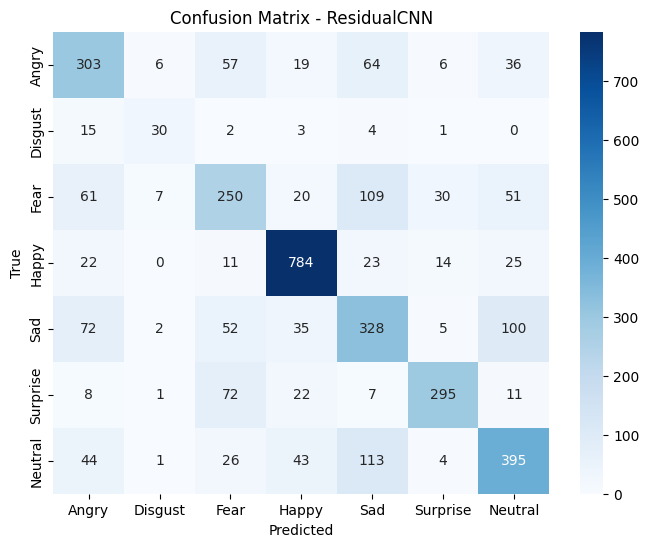

              precision    recall  f1-score   support

       Angry       0.58      0.62      0.60       491
     Disgust       0.64      0.55      0.59        55
        Fear       0.53      0.47      0.50       528
       Happy       0.85      0.89      0.87       879
         Sad       0.51      0.55      0.53       594
    Surprise       0.83      0.71      0.77       416
     Neutral       0.64      0.63      0.64       626

    accuracy                           0.66      3589
   macro avg       0.65      0.63      0.64      3589
weighted avg       0.67      0.66      0.66      3589



In [44]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - ResidualCNN")
plt.savefig("confusion_matrix_residualcnn.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [45]:
wandb.init(
    project="fer2013-homework",
    name="Final_Evaluation_ResidualCNN"
)

wandb.log({
    "test_accuracy": test_acc,
    "test_loss": test_loss,
    "confusion_matrix": wandb.Image("confusion_matrix_residualcnn.png")
})

wandb.finish()

test_accuracy,▁
test_loss,▁
test_accuracy,0.66453
test_loss,1.07495
